In [19]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [20]:
class AgentState(TypedDict):
    number1: int
    operation: str
    number2: int
    number3: int
    number4: int
    operation2: str
    finalNumber1: int
    finalNumber2: int

In [21]:
def adder(state: AgentState) -> AgentState:
    """This node adds the 2 numbers"""

    state['finalNumber1'] = state['number1'] + state['number2']
    return state

def subtractor(state: AgentState) -> AgentState:
    """This node subtracts the 2 numbers"""

    state['finalNumber1'] = state['number1'] - state['number2']
    return state

def adder2(state: AgentState) -> AgentState:
    """This node adds the 2 numbers"""

    state['finalNumber2'] = state['number3'] + state['number4']
    return state

def subtractor2(state: AgentState) -> AgentState:
    """This node subtracts the 2 numbers"""

    state['finalNumber2'] = state['number3'] - state['number4']
    return state

def decide_next_node(state: AgentState) -> AgentState:
    """This node will select the next node of the graph"""

    if state['operation'] == "+":
        return "addition_operation"
    
    if state['operation'] == "-":
        return "subtraction_operation"
    
def decide_next_node2(state: AgentState) -> AgentState:
    """This node will select the next node of the graph"""

    if state['operation2'] == "+":
        return "addition_operation2"
    
    if state['operation2'] == "-":
        return "subtraction_operation2"

In [22]:
graph = StateGraph(AgentState)

graph.add_node("adder", adder)
graph.add_node("subtractor", subtractor)
graph.add_node("router", lambda state: state)

graph.add_node("adder2", adder2)
graph.add_node("subtractor2", subtractor2)
graph.add_node("router2", lambda state: state)

graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        "addition_operation": "adder",
        "subtraction_operation": "subtractor"
    }
)

graph.add_edge("adder", "router2")
graph.add_edge("subtractor","router2")

graph.add_conditional_edges(
    "router2",
    decide_next_node2,
    {
        "addition_operation2": "adder2",
        "subtraction_operation2": "subtractor2"
    }
)

graph.add_edge("adder2", END)
graph.add_edge("subtractor2", END)

app = graph.compile()

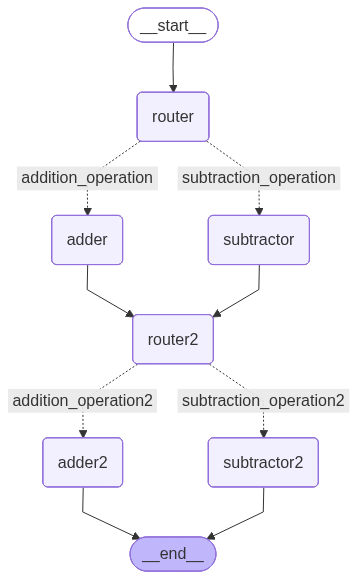

In [23]:
from IPython.display import Image

display(Image(app.get_graph().draw_mermaid_png()))

In [24]:
result = app.invoke({"number1": 12, "operation": "-", "number2": 13, "number3": 2, "number4": 5, "operation2": "+"})
print(result)

{'number1': 12, 'operation': '-', 'number2': 13, 'number3': 2, 'number4': 5, 'operation2': '+', 'finalNumber1': -1, 'finalNumber2': 7}
